In [1]:
import scarf

scarf.configure_output(level='WARNING', progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    'kang_15K_pbmc_rnaseq',
    destination='scarf_datasets',
    zarr=True,
)
ds = scarf.DataStore(
    f'{dataset}/data.zarr',
    nthreads=4,
)

Downloading bucket files: 56411732 / 56411732 complete

Downloading bytes: 56411732 / 56411732 complete

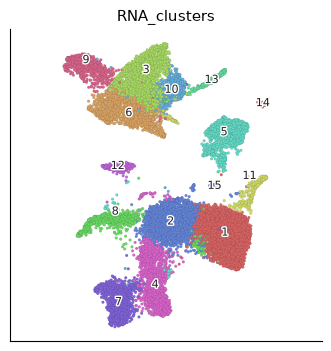

In [2]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_clusters',
)

In [3]:
ds.run_marker_search(group_key='RNA_clusters')
markers = ds.get_markers(
    group_key='RNA_clusters',
    group_id='1',
    min_score=-1,
    min_frac_exp=-1,
)
markers[
    [
        'feature_name',
        'score',
        'frac_exp',
        'auc',
        'p_value',
        'p_value_adjusted',
    ]
].head()

Finding markers: 1 / 1 complete

,feature_name,score,frac_exp,auc,p_value,p_value_adjusted
0,CD27,0.31349,0.27051,0.60652,3.473901e-247,4.295932e-245
1,LINC00861,0.30415,0.09085,0.53767,7.947568e-98,3.675588e-96
2,NELL2,0.29848,0.14068,0.55269,2.740063e-105,1.349511e-103
3,LEF1,0.29472,0.30542,0.62260,1.821220e-298,2.800003e-296
4,FAM134B,0.29009,0.07729,0.52957,7.037775e-62,2.037373e-60


Aggregating marker values per group: 4 / 4 complete

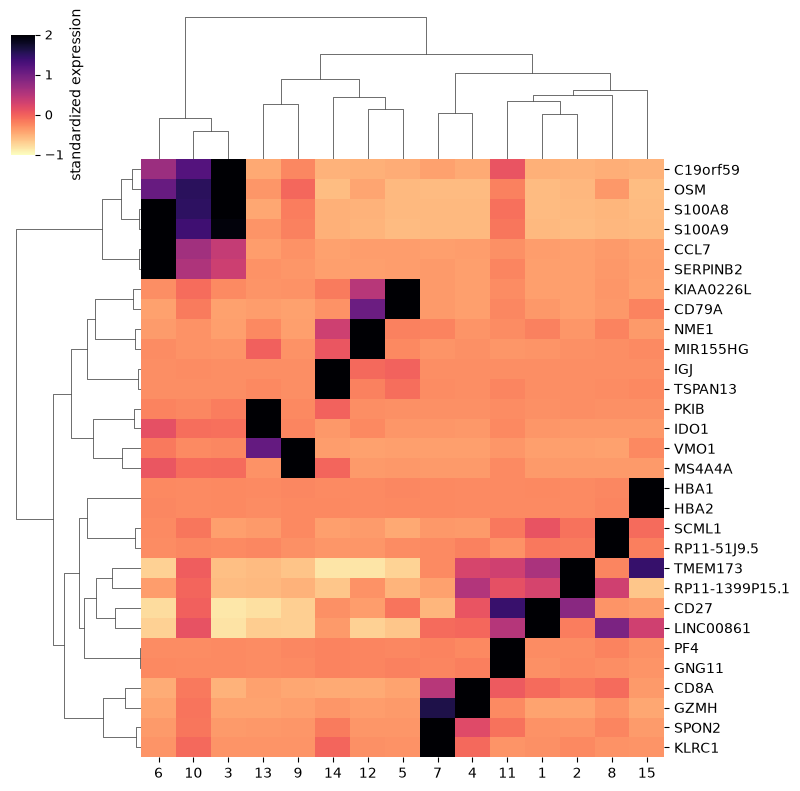

In [4]:
ds.plots.marker_heatmap(
    group_key='RNA_clusters',
    topn=2,
    figsize=(8, 8),
)

In [5]:
bulk = ds.make_bulk(
    group_key='RNA_clusters',
    aggr_type='sum',
    feature_label='name',
)
bulk.iloc[:5, :5]

Aggregating pseudo-replicates: 15 / 15 complete

,1,2,3,4,5
RP11-34P13.8,0,0,0,0,0
AL627309.1,1,2,0,1,0
RP11-206L10.2,1,0,2,0,1
RP11-206L10.9,2,0,0,1,1
FAM87B,0,0,0,0,1


In [6]:
bulk_reps = ds.make_bulk(
    group_key='RNA_clusters',
    aggr_type='sum',
    feature_label='name',
    pseudo_reps=2,
)
bulk_reps.shape

Aggregating pseudo-replicates: 15 / 15 complete

(17654, 30)

In [7]:
export_path = 'scarf_datasets/kang_pseudobulk_counts.csv'
bulk.to_csv(export_path)
print(f'Wrote {bulk.shape[0]} features x {bulk.shape[1]} groups to {export_path}')

Wrote 17654 features x 15 groups to scarf_datasets/kang_pseudobulk_counts.csv
